<a href="https://colab.research.google.com/github/DawidSkowronski/PyTorch-Projects/blob/main/PyTorch_Tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classification with DNN - Iris dataset

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
%matplotlib inline

import pandas as pd
pd.set_option('future.no_silent_downcasting', True)

from sklearn.model_selection import train_test_split

In [2]:
# Loading data
url='https://gist.githubusercontent.com/netj/8836201/raw/6f9306ad21398ea43cba4f7d537619d0e07d5ae3/iris.csv'

df = pd.read_csv(url)

In [3]:
df.head(3)

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa


In [ ]:
# Change variety column from str to float
df['variety'] = df['variety'].replace({
    'Setosa': 0,
    'Versicolor': 1,
    'Virginica': 2
}).astype(int)

In [ ]:
df

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [ ]:
# Train test Split

X = df.drop('variety', axis=1)
Y = df['variety']

In [ ]:
# Convert X, Y to numpy arrays
X=X.values
Y=Y.values

In [ ]:
# Train and test set split

X_train, X_test, Y_train, Y_test = train_test_split(X,Y,
                                                    train_size=0.8,
                                                    random_state=42)

In [ ]:
# Convert arrays to tensor
# X features to float tensors
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)

# Y labels to tensors long (int)
Y_train = torch.LongTensor(Y_train)
Y_test = torch.LongTensor(Y_test)

# Creating the DNN model

In [ ]:
# Model Class that inherits from nn.Module

class Model(nn.Module):
  # Input layer (4 characteristics of iris flower)
  # Hidden layer
  # Output layer (3 species of iris)

  # Number of neurons in each layer
  def __init__(self, input_number = 4,
               hidden1_number = 8,
               hidden2_number = 4,
               output_number = 3):
    super().__init__() # initiate nn.Module

  # fc - fully connected
    self.fc1 = nn.Linear(input_number, hidden1_number)
    self.fc2 = nn.Linear(hidden1_number, hidden2_number)
    self.out = nn.Linear(hidden2_number, output_number)

  # Forward propagation
  def forward(self, X):
    # Move data through layers
    X = F.relu(self.fc1(X))
    X = F.relu(self.fc2(X))
    X = self.out(X)

    return X




In [ ]:
# Set seed for repeatability
torch.manual_seed(42)

# Create instance of Model
model = Model()

In [ ]:
# Criterion for model to measure prediction error
criterion = nn.CrossEntropyLoss()

# Adam Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr = 0.01)


In [ ]:
# Epochs
epochs = 200

losses = []

for epoch in range(epochs):
  Y_predict = model.forward(X_train) # Get predicted results

  # Measure the error
  loss = criterion(Y_predict, Y_train)

  # History of losses
  losses.append(loss.detach().numpy())
  # The expression .detach().numpy() is used in PyTorch when converting a torch

  # Print progress
  if epoch % 10 ==0:
    print(f"Epoch: {epoch}, loss: {loss}")

  # Back propagation

  optimizer.zero_grad() # Clears the old gradient values
  loss.backward()
  # Performs backpropagation to calculate the new gradients of the loss
  # with respect to each parameter (weights)
  optimizer.step()
  # Uses the calculated gradients to update the model's parameters

Epoch: 0, loss: 1.4084850549697876
Epoch: 10, loss: 1.096941351890564
Epoch: 20, loss: 1.0314691066741943
Epoch: 30, loss: 0.9239533543586731
Epoch: 40, loss: 0.8214181661605835
Epoch: 50, loss: 0.7241766452789307
Epoch: 60, loss: 0.5573097467422485
Epoch: 70, loss: 0.446953684091568
Epoch: 80, loss: 0.3555295169353485
Epoch: 90, loss: 0.248922660946846
Epoch: 100, loss: 0.15556806325912476
Epoch: 110, loss: 0.10541171580553055
Epoch: 120, loss: 0.08271186798810959
Epoch: 130, loss: 0.07194407284259796
Epoch: 140, loss: 0.06621211022138596
Epoch: 150, loss: 0.06280769407749176
Epoch: 160, loss: 0.06057717651128769
Epoch: 170, loss: 0.05899021402001381
Epoch: 180, loss: 0.05779796838760376
Epoch: 190, loss: 0.056858886033296585


Text(0.5, 0, 'Epoch')

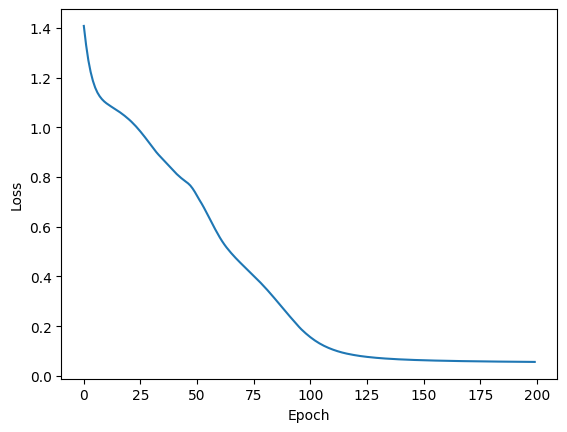

In [ ]:
# Loss history plot

plt.plot(range(epochs), losses)
plt.ylabel("Loss")
plt.xlabel("Epoch")

# Model evaluation

In [ ]:
# Validate the model on Test Data Set

# Send test data thru model, without changing parameters
with torch.no_grad(): # Trun off back propagation
  Y_eval = model.forward(X_test)
  loss = criterion(Y_eval, Y_test)


In [ ]:
loss

tensor(0.0500)

In [ ]:
correct = 0
with torch.no_grad():
  for i, data in enumerate(X_test):
    Y_value = model.forward(data)

    # What species of iris was pointed by the model
    print(f"({i+1}.) {str(Y_value)} \t {Y_test[i]} \t {Y_value.argmax().item()}")

    # Check if the model prediction is correct
    if Y_value.argmax().item() == Y_test[i]:
      correct += 1

print()
print(f"Number of correct predictions: {correct}")

(1.) tensor([-3.0206,  8.6194,  3.5867]) 	 1 	 1
(2.) tensor([ 13.0280,   5.6015, -17.8056]) 	 0 	 0
(3.) tensor([-16.8386,  10.4677,  22.3086]) 	 2 	 2
(4.) tensor([-3.7051,  8.4890,  4.5264]) 	 1 	 1
(5.) tensor([-3.5804,  9.2154,  4.3029]) 	 1 	 1
(6.) tensor([ 12.1933,   5.2252, -16.6605]) 	 0 	 0
(7.) tensor([ 1.1822,  7.6774, -2.0274]) 	 1 	 1
(8.) tensor([-9.4755,  9.1902, 12.3281]) 	 2 	 2
(9.) tensor([-6.0433,  8.1495,  7.7263]) 	 1 	 1
(10.) tensor([-0.0179,  7.9792, -0.4348]) 	 1 	 1
(11.) tensor([-7.8823,  8.9952, 10.1774]) 	 2 	 2
(12.) tensor([ 11.2731,   4.6923, -15.3907]) 	 0 	 0
(13.) tensor([ 12.5257,   5.2106, -17.1061]) 	 0 	 0
(14.) tensor([ 11.5293,   4.7983, -15.7416]) 	 0 	 0
(15.) tensor([ 12.2794,   5.2038, -16.7749]) 	 0 	 0
(16.) tensor([-3.2933,  9.0397,  3.9295]) 	 1 	 1
(17.) tensor([-13.3292,   8.7994,  17.6087]) 	 2 	 2
(18.) tensor([-0.4512,  7.7803,  0.1600]) 	 1 	 1
(19.) tensor([-3.3399,  8.2002,  4.0512]) 	 1 	 1
(20.) tensor([-13.0934,   8.6250,  

In [ ]:
# Accuracy
# FP, TP, FN, TN
# specificity,

In [ ]:
# Evaluating New Data
